# 7. See how a model learns
## Goal
Implement gradient descent for a line and compare a linear classifier with a small neural network on synthetic curved classes.
Course Module 11. This is a foundation exercise; it does not train a large deep-learning model.
## Setup
Uses NumPy, scikit-learn, and Matplotlib. No GPU or network access required.
References: [Google MLCC](https://developers.google.com/machine-learning/crash-course), [PyTorch basics for the next step](https://docs.pytorch.org/tutorials/beginner/basics/intro.html).
## Steps
### 1. Fit a line using visible arithmetic
These 100 noiseless pairs are a numerical optimization demonstration. They are not a train/test performance claim.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-1, 1, 100)
y = 3*x + 2
w, b = 0.0, 0.0
learning_rate = 0.1
losses = []
for step in range(150):
    error = w*x + b - y
    losses.append(np.mean(error**2))
    gradient_w = 2*np.mean(error*x)
    gradient_b = 2*np.mean(error)
    w -= learning_rate * gradient_w
    b -= learning_rate * gradient_b
print(f"Learned weight={w:.4f}, bias={b:.4f}")
print(f"Loss: {losses[0]:.4f} → {losses[-1]:.8f}")
assert losses[-1] < losses[0]
assert np.isclose(w, 3, atol=0.001) and np.isclose(b, 2, atol=0.001)

Learned weight=2.9999, bias=2.0000
Loss: 7.0606 → 0.00000000


### 2. Plot the optimization trace
Loss is squared error in this numeric demonstration.

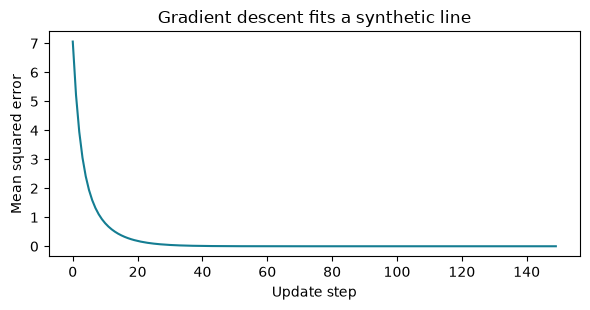

In [2]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(losses, color="#147d92")
ax.set(title="Gradient descent fits a synthetic line", xlabel="Update step", ylabel="Mean squared error")
fig.tight_layout()
plt.show()

### 3. Define two fixed classification candidates
Two interlocking curved groups are generated using `make_moons`. Compare candidates on validation data before revealing the test. Class 1 is the positive class; balanced classes and equal example costs make accuracy a useful first metric here.

In [3]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

features, labels = make_moons(n_samples=600, noise=0.20, random_state=42)
X_develop, X_test, y_develop, y_test = train_test_split(features, labels, test_size=0.2, stratify=labels, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_develop, y_develop, test_size=0.25, stratify=y_develop, random_state=42)
models = {
    "linear": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "neural": make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(12,), activation="tanh", solver="lbfgs", alpha=0.1, max_iter=2000, random_state=42)),
}
validation_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    validation_scores[name] = accuracy_score(y_valid, model.predict(X_valid))
    print(name, "validation accuracy:", round(validation_scores[name], 3))
winner = max(validation_scores, key=validation_scores.get)
print("Chosen before test evaluation:", winner)

linear validation accuracy: 0.9
neural validation accuracy: 0.958
Chosen before test evaluation: neural


### 4. Refit the chosen architecture and test once
The library trains the network; Step 1 showed the update principle. This neural model uses a different numerical optimizer (`lbfgs`), so its internal updates are not identical to our simple loop.

In [4]:
model = models[winner]
model.fit(X_develop, y_develop)
test_predictions = model.predict(X_test)
print("Final test accuracy:", round(accuracy_score(y_test, test_predictions), 3))
print("Confusion matrix: rows = actual 0/1; columns = predicted 0/1")
print(confusion_matrix(y_test, test_predictions, labels=[0, 1]))
assert len(test_predictions) == len(y_test)
assert set(np.unique(test_predictions)) <= {0, 1}

Final test accuracy: 0.983
Confusion matrix: rows = actual 0/1; columns = predicted 0/1
[[59  1]
 [ 1 59]]


## Checks
Explain a weight, bias, activation, loss, gradient, learning rate, and inference. Explain why a hidden nonlinearity can help these generated curved groups. Results are bounded to this teaching dataset and split.
## Next Steps
Exercises 36–37. For a real framework extension follow the official PyTorch tutorial after understanding the calculations here. Changing this example based on the revealed test makes that test part of development history.